# MNE Practice
We are gonna be using one of the example datasets provided in MNE called "sample" which contains EEG and MEG data from one subject performing an audiovisual experiment, along with structural MRI scans for that subjects

In this document, I will be practicing the pipeline for event-related analysis which includes loading data, epoching, averaging, plotting and estimating cortical activity from sensor data

We can use `mne.datasets.sample.data.path` function to automatically downlaod the dataset if it hasn't been downloaded yet

In [1]:
import numpy as np
import mne

## Loading Data

In [2]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
)
raw = mne.io.read_raw_fif(sample_data_raw_file)

Using default location ~/mne_data for sample...
Creating C:\Users\auran\mne_data
Fetching 1 file for the sample dataset ...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of 'C:\Users\auran\mne_data\MNE-sample-data-processed.tar.gz' to 'C:\Users\auran\mne_data'


Attempting to create new mne-python configuration file:
C:\Users\auran\.mne\mne-python.json
Could not read the C:\Users\auran\.mne\mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 10m59s (1576.2 MB)
Opening raw data file C:\Users\auran\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


In [3]:
print(raw)
print(raw.info)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~3.2 MiB, data not loaded>
<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).
Using matplotlib as 2D backend.


d:\Documents\Staj\.venv-tribe\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


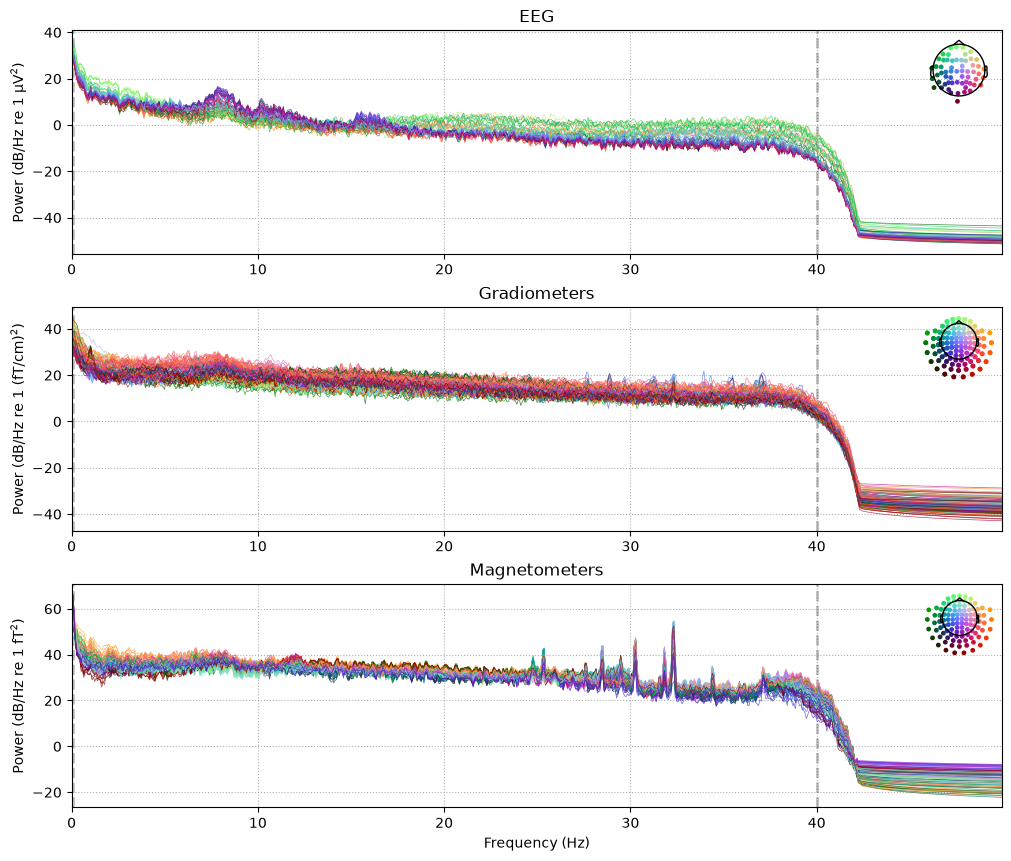

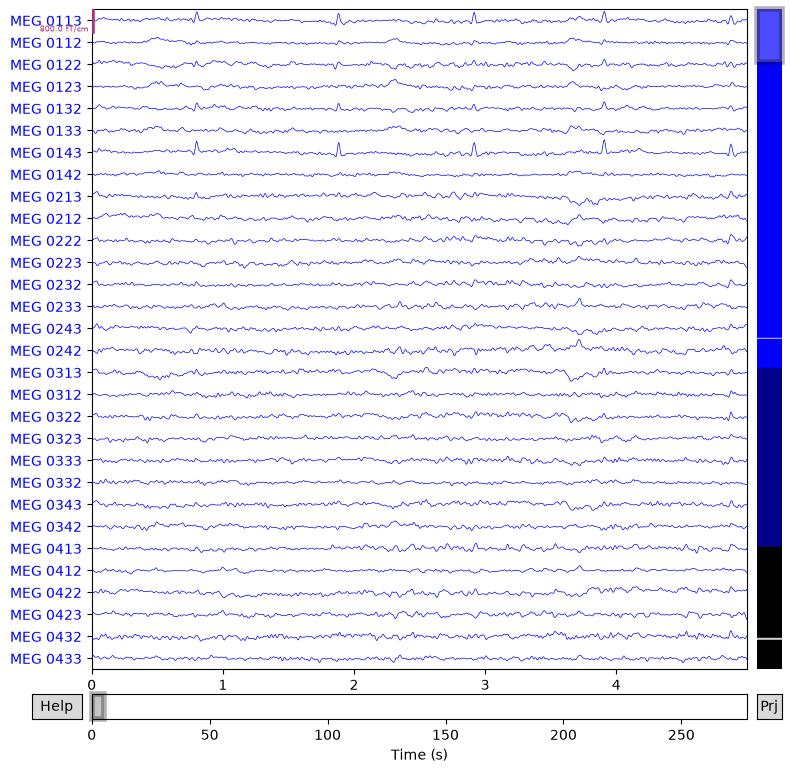

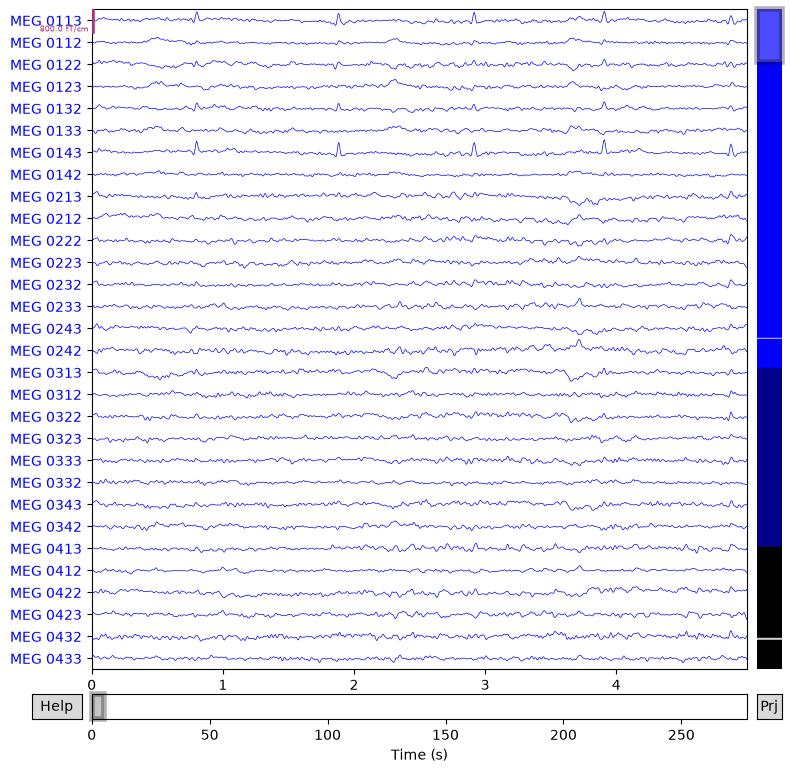

In [4]:
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

## Preprocessing
we can access the preprocessing in mne.preprocessing and mne.filter submodules but in this example we will use ICA (Independent Components Analysis)

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 11.5s.
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


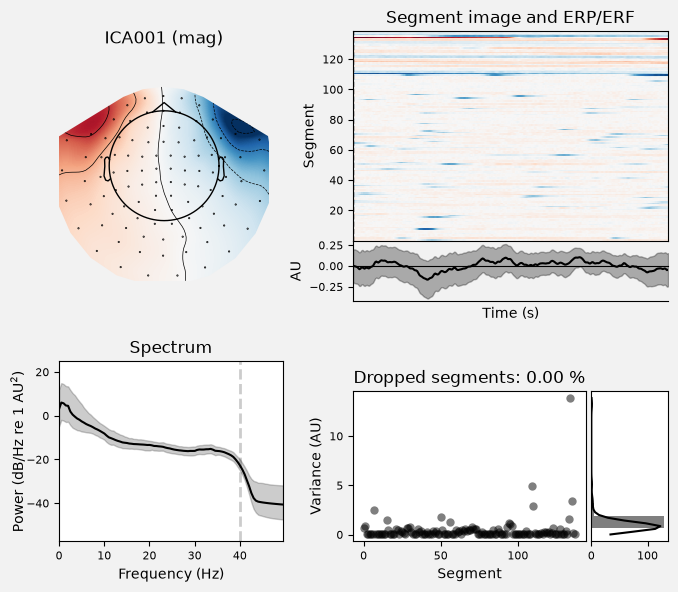

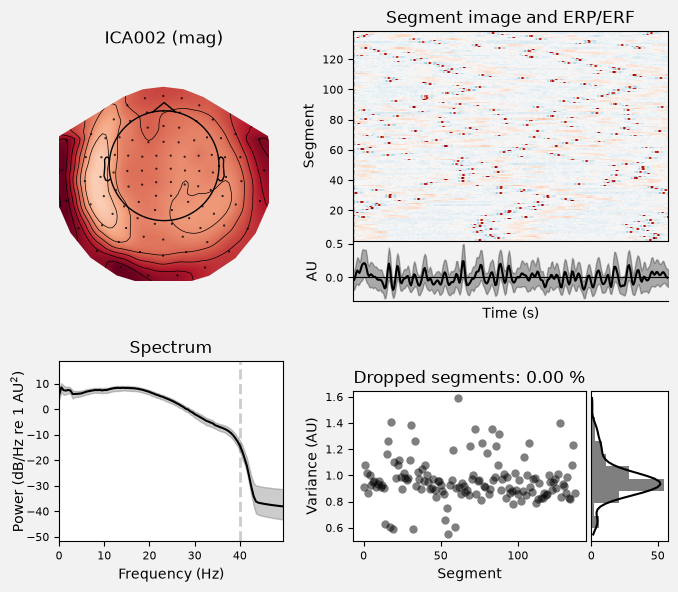

[<Figure size 700x600 with 6 Axes>, <Figure size 700x600 with 6 Axes>]

In [5]:
# set up and fit the ICA
ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(raw)
ica.exclude = [1, 2]  # details on how we picked these are omitted here
ica.plot_properties(raw, picks=ica.exclude)

Once we’re confident about which component(s) we want to remove, we pass them as the exclude parameter and then apply the ICA to the raw signal. 
- The `apply` method requires the raw data to be loaded into memory (by default it’s only read from disk as-needed), so we’ll use `load_data` first.
- We’ll also make a copy of the `Raw` object so we can compare the signal before and after artifact removal side-by-side

Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 364 PCA components


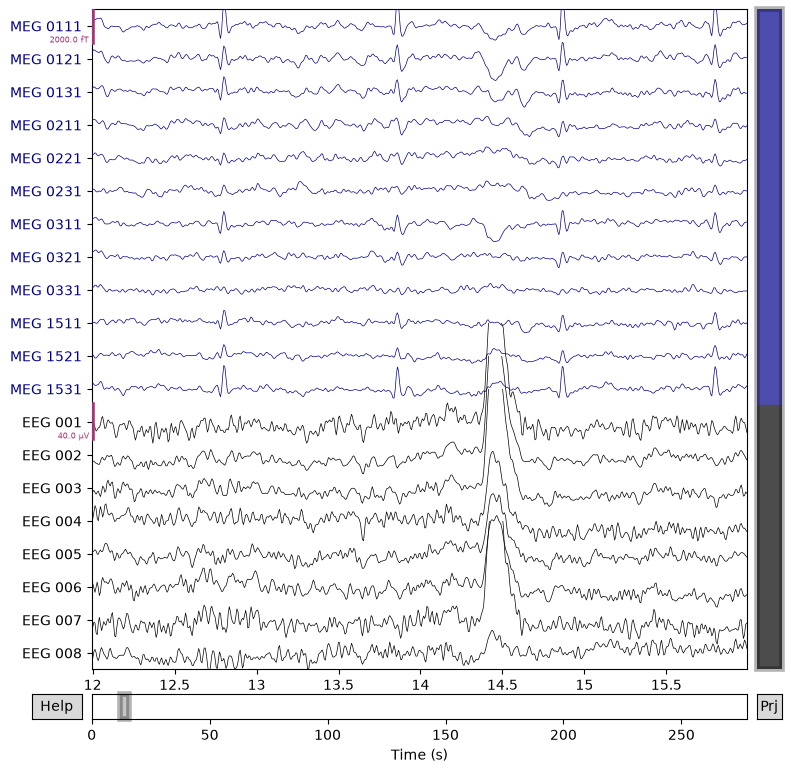

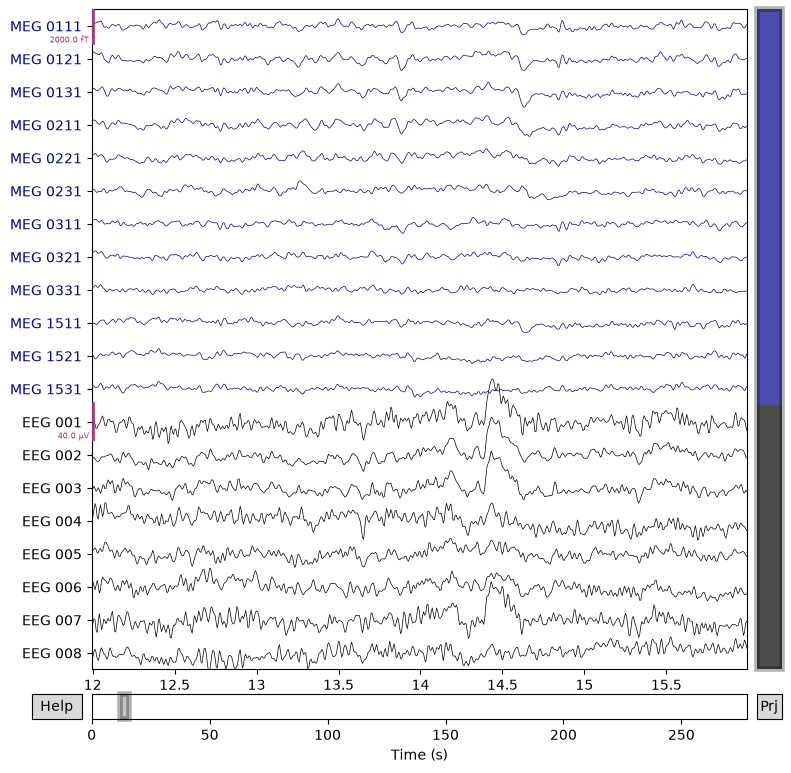

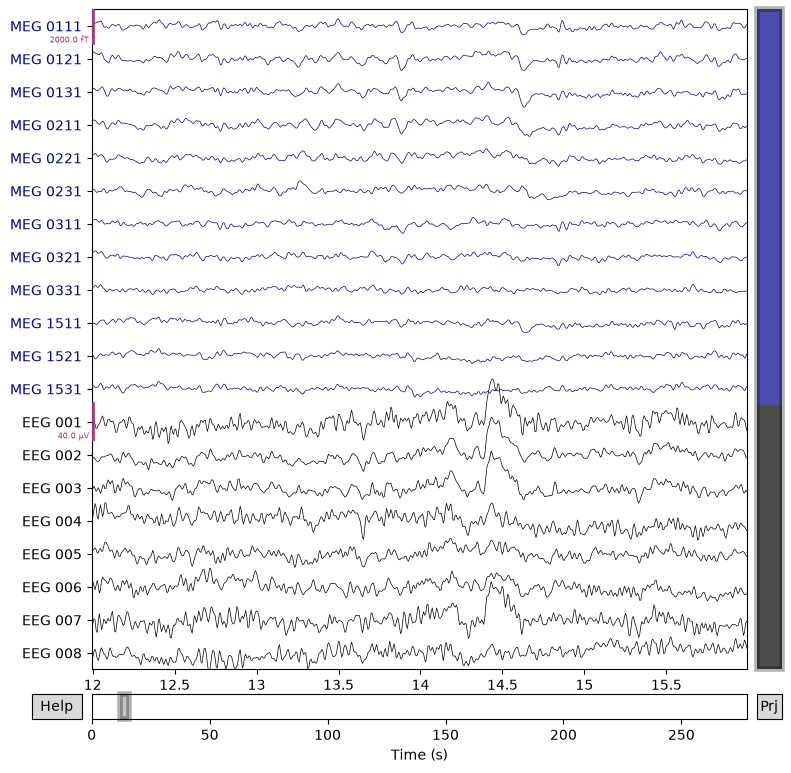

In [6]:
orig_raw = raw.copy()
raw.load_data()
ica.apply(raw)

# show some frontal channels to clearly illustrate the artifact removal
chs = [
    "MEG 0111",
    "MEG 0121",
    "MEG 0131",
    "MEG 0211",
    "MEG 0221",
    "MEG 0231",
    "MEG 0311",
    "MEG 0321",
    "MEG 0331",
    "MEG 1511",
    "MEG 1521",
    "MEG 1531",
    "EEG 001",
    "EEG 002",
    "EEG 003",
    "EEG 004",
    "EEG 005",
    "EEG 006",
    "EEG 007",
    "EEG 008",
]
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
orig_raw.plot(order=chan_idxs, start=12, duration=4)
raw.plot(order=chan_idxs, start=12, duration=4)

## Detecting experimental events
The dataset includes several "STIM" channels that recorded electrical signals sent from the stimulus delivery computer. These pulses (often called “triggers”) are used in this dataset to mark experimental events: stimulus onset, stimulus type, and participant response (button press). The individual STIM channels are combined onto a single channel, in such a way that voltage levels on that channel can be unambiguously decoded as a particular event type. 

In [7]:
events = mne.find_events(raw, stim_channel="STI 014")
print(events[:5])

Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
[[6994    0    2]
 [7086    0    3]
 [7192    0    1]
 [7304    0    4]
 [7413    0    2]]


The resulting events array is an ordinary 3-column NumPy array, with:
- sample number in the first column
- integer event ID in the last column

The middle column is usually ignored and rather than keeping track of integer event IDs, we can provide an event dictionary that maps the integer IDs to experimental conditions or events.

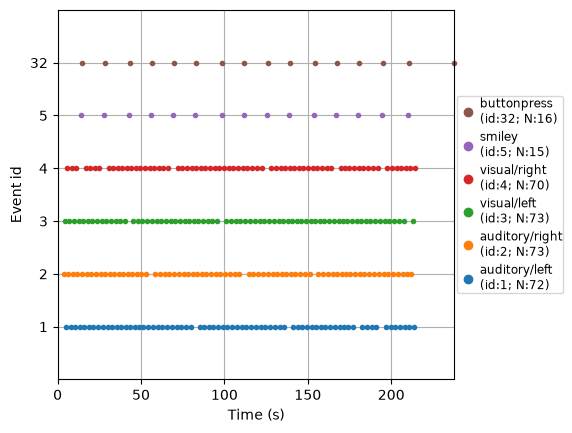

In [9]:
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "smiley": 5,
    "buttonpress": 32,
}

fig = mne.viz.plot_events(
    events, event_id=event_dict, sfreq=raw.info["sfreq"], first_samp=raw.first_samp
)

Event dictionaries like this one are used when extracting epochs from continuous data. There is also a convenient `plot_events` function for visualizing tthe distribution of events across the duration of the recording

## Epoching continuous data
The `Raw` object and the events array are the bare minimum needed to create an Epochs object, which we create with the Epochs class constructor

In [11]:
reject_criteria = dict(
    mag=4000e-15,  # 4000 fT
    grad=4000e-13,  # 4000 fT/cm
    eeg=150e-6,  # 150 µV
    eog=250e-6, # 250 µV
)

# We can also use autoreject package for automated rejection of bad epochs.It
# It uses a cross-validation approach to find the optimal rejection thresholds for each channel type.
# This can be particularly useful when dealing with large datasets or when the noise characteristics vary across channels.

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2,
    tmax=0.5,
    reject=reject_criteria,
    preload=True,
)

Not setting metadata
319 matching events found


Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Using data from preloaded Raw for 319 events and 106 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EEG : ['EEG 008']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
10 bad epochs dropped


In [12]:
# Pooling across left and right stimulus presentations so we can compare auditory vs visual responses
conds_we_want = ["auditory/left", "auditory/right", "visual/left", "visual/right"]
epochs.equalize_event_counts(conds_we_want)
auditory_epochs = epochs["auditory"]
visual_epochs = epochs["visual"]
del raw, epochs # This is to free up memory, as we won't be using these objects anymore.

Dropped 7 epochs: 121, 195, 258, 271, 273, 274, 275


Not setting metadata
136 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
136 matching events found
No baseline correction applied
0 projection items activated


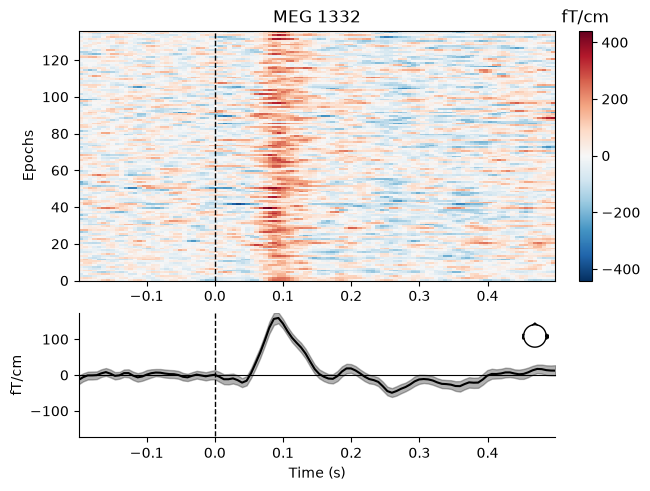

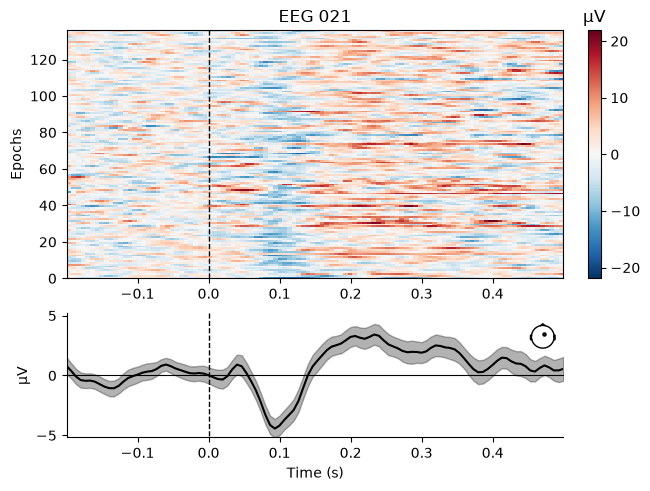

[<Figure size 640x480 with 4 Axes>, <Figure size 640x480 with 4 Axes>]

In [13]:
auditory_epochs.plot_image(picks=["MEG 1332", "EEG 021"])

## Time-frequency analysis
The `mne.time_frequency` submodule provides implemenntatinos of several algorithms to compute time-frequency representations, power spectral density and cross-spectral density. In this example I am coputing for the auditory epochs the induced power at different freqs and times using Morlet wavelets

No baseline correction applied


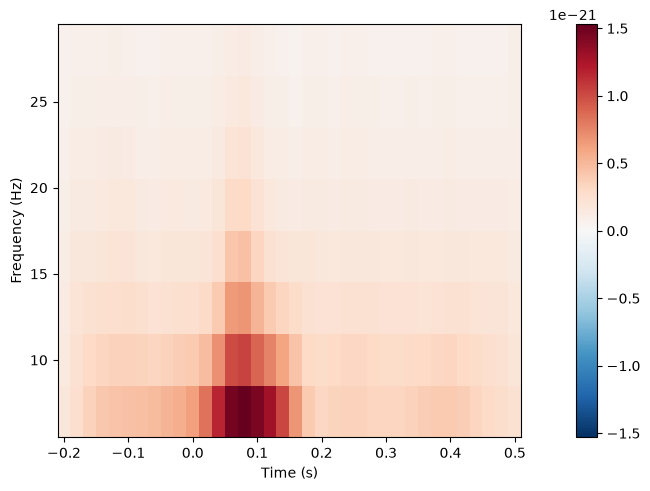

[<Figure size 640x480 with 2 Axes>]

In [15]:
frequencies = np.arange(7, 30, 3)  # define frequencies of interest

power = auditory_epochs.compute_tfr(
    "morlet", n_cycles=2, return_itc=False, freqs=frequencies, decim=3, average=True
)

power.plot(["MEG 1332"])

# n_cycles is a parameter that specifies the number of cycles in the Morlet wavelet. In this case, we are using 2 cycles, which means that the wavelet will have a duration of 2/frequency seconds. This parameter can be adjusted to trade off temporal and frequency resolution in the time-frequency analysis.
# decim is a parameter that specifies the decimation factor to apply to the time-frequency representation. In this case, we are using a decimation factor of 3, which means that the time-frequency representation will be downsampled by a factor of 3. This can help reduce the size of the output and speed up subsequent analyses.
# average is a parameter that specifies whether to average the time-frequency representation across epochs. In this case, we are setting average=True, which means that the output will be a single time-frequency representation that represents the average power across all epochs. If average=False, the output will be a 3D array with dimensions (n_epochs, n_frequencies, n_times), where n_epochs is the number of epochs in the input data.

## Estimating evoked responses
Now that we have our conditions in `audtory_epochs` and `visual_epochs`, we can get an estimate of evoked responses to auditory versus visual stimuli by averaging together the epochs in each condition.
This is as simple as calling the average method on the `Epochs` object, and then using a function from the `mne.viz` module to compare the global field power for each sensor type of the two `Evoked` objects

Multiple channel types selected, returning one figure per type.
combining channels using RMS (grad channels)
combining channels using RMS (grad channels)


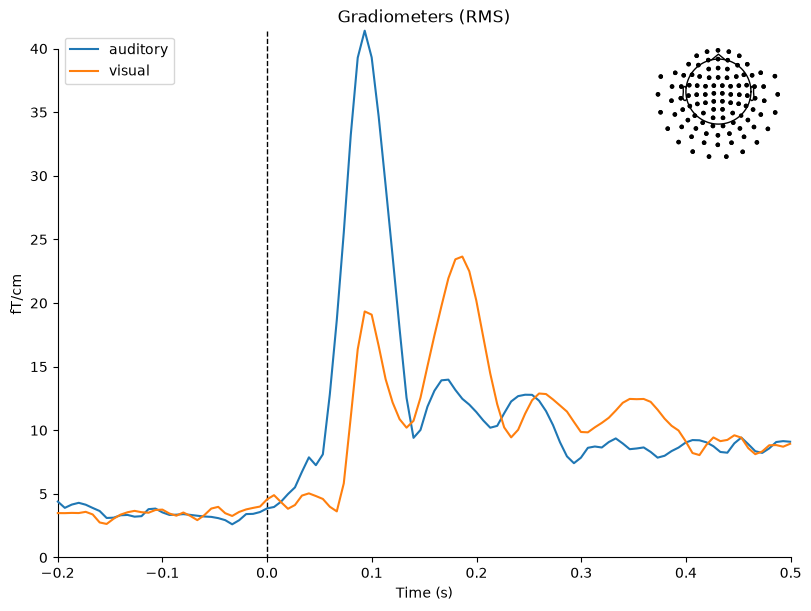

combining channels using RMS (mag channels)
combining channels using RMS (mag channels)


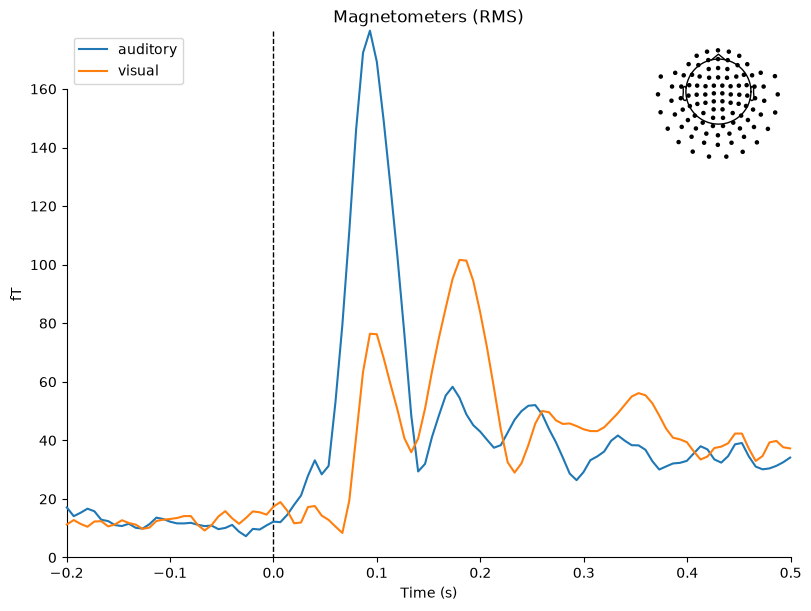

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


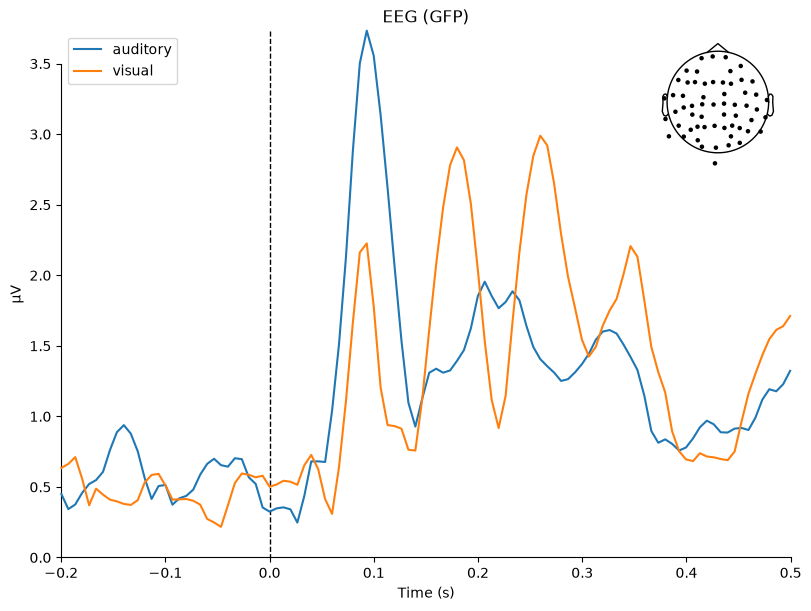

[<Figure size 800x600 with 2 Axes>,
 <Figure size 800x600 with 2 Axes>,
 <Figure size 800x600 with 2 Axes>]

In [16]:
auditory_evoked = auditory_epochs.average()
visual_evoked = visual_epochs.average()

mne.viz.plot_compare_evokeds(
    dict(auditory=auditory_evoked, visual=visual_evoked),
    legend="upper left",
    show_sensors="upper right",
)

We can also get a more detailed view of each `Evoked` object using other plotting methods such as `plot_joint` or `plot_topomap`. Here we’ll examine just the EEG channels, and see the classic auditory evoked N100-P200 pattern over dorso-frontal electrodes, then plot scalp topographies at some additional arbitrary times

Projections have already been applied. Setting proj attribute to True.


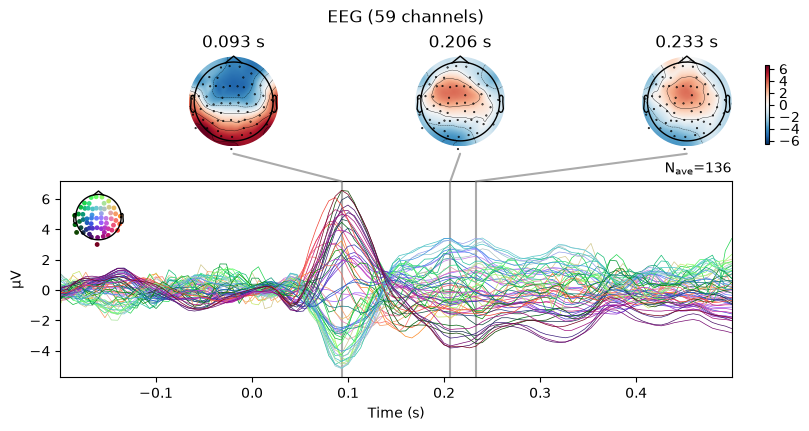

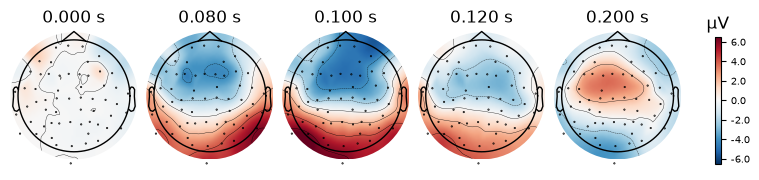

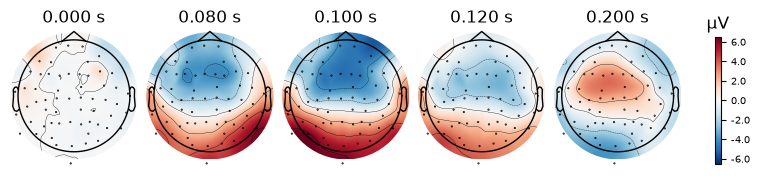

In [17]:
auditory_evoked.plot_joint(picks="eeg")
auditory_evoked.plot_topomap(times=[0.0, 0.08, 0.1, 0.12, 0.2], ch_type="eeg")

Evoked objects can also be combined to show contrasts between conditions, using the `mne.combine_evoked` function. A simple difference can be generated by passing `weights=[1, -1]`. We’ll then plot the difference wave at each sensor using `plot_topo`

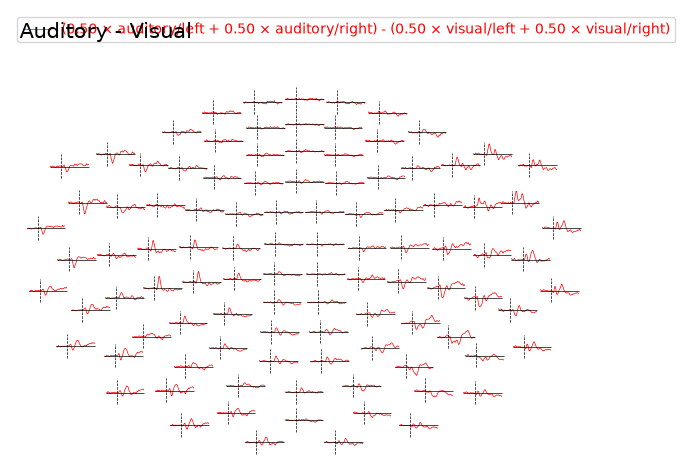

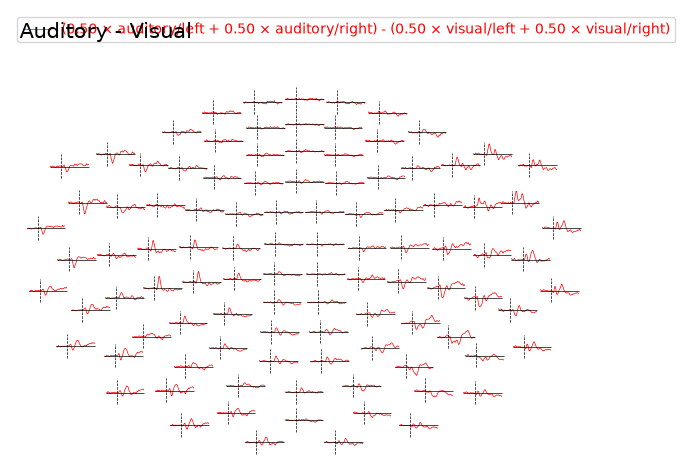

In [19]:
evoked_diff = mne.combine_evoked([auditory_evoked, visual_evoked], weights=[1, -1])
evoked_diff.pick(picks="mag").plot_topo(color="r", title="Auditory - Visual", legend="upper left")

## Inverse modelling
Finally, we can estimate the origins of the evoked activity by projecting the sensor data into this subject’s source space (a set of points either on the cortical surface or within the cortical volume of that subject, as estimated by structural MRI scans). MNE-Python supports lots of ways of doing this (dynamic statistical parametric mapping, dipole fitting, beamformers, etc.); here we’ll use minimum-norm estimation (MNE) to generate a continuous map of activation constrained to the cortical surface. 

MNE uses a linear inverse operator to project EEG+MEG sensor measurements into the source space. The inverse operator is computed from the forward solution for this subject and an estimate of the covariance of sensor measurements.

In [25]:
# load inverse operator
inverse_operator_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis-meg-oct-6-meg-inv.fif"
)
inv_operator = mne.minimum_norm.read_inverse_operator(inverse_operator_file)
# set signal-to-noise ratio (SNR) to compute regularization parameter (λ²)
snr = 3.0
lambda2 = 1.0 / snr**2
# generate the source time course (STC)
stc = mne.minimum_norm.apply_inverse(
    visual_evoked, inv_operator, lambda2=lambda2, method="MNE"
)  # or dSPM, sLORETA, eLORETA

Reading inverse operator decomposition from C:\Users\auran\mne_data\MNE-sample-data\MEG\sample\sample_audvis-meg-oct-6-meg-inv.fif...
    Reading inverse operator info...
    [done]
    Reading inverse operator decomposition...
    [done]
    305 x 305 full covariance (kind = 1) found.
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Noise covariance matrix read.
    22494 x 22494 diagonal covariance (kind = 2) found.
    Source covariance matrix read.
    22494 x 22494 diagonal covariance (kind = 6) found.
    Orientation priors read.
    22494 x 22494 diagonal covariance (kind = 5) found.
    Depth priors read.
    Did not find the desired covariance matrix (kind = 3)
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing 

Finally, in order to plot the source estimate on the subject’s cortical surface we’ll also need the path to the sample subject’s structural MRI files (the `subjects_dir`)

In [28]:
# path to subjects' MRI files
subjects_dir = sample_data_folder / "subjects"
# plot the STC
stc.plot(
    initial_time=0.1,
    hemi="split",
    views=["lat", "med"],
    subjects_dir=subjects_dir
)

RuntimeError: Could not load any valid 3D backend
pyvistaqt: No module named 'qtpy'
notebook: No module named 'ipyevents'

 install pyvistaqt, using pip or conda:
'pip install pyvistaqt'
'conda install -c conda-forge pyvistaqt'

 or install ipywidgets, if using a notebook backend
'pip install ipywidgets'
'conda install -c conda-forge ipywidgets'